In [8]:
import os
import ctypes
import sys

# --- Définir les paths pour les libs locales ---
home = os.path.expanduser("~")
local_lib = os.path.join(home, "local", "lib")
local_include = os.path.join(home, "local", "include")
print(home)
# Ajouter les chemins aux variables d'environnement
os.environ["LD_LIBRARY_PATH"] ="/gpfs/users/ouadjout/local/lib:/gpfs/users/ouadjout/local/lib:/gpfs/softs/spack_1.0.2/opt/spack/linux-cascadelake/fftw-3.3.10-5yypb3xo652o26vdc6w5bag5wj7ik7zp/lib:/gpfs/softs/spack_1.0.2/opt/spack/linux-cascadelake/fftw-3.3.10-5yypb3xo652o26vdc6w5bag5wj7ik7zp/lib64:/gpfs/softs/spack_1.0.2/opt/spack/linux-cascadelake/openmpi-4.1.8-ex7uem7tsbaraet3ngajeygzwa4tfd76/lib:/gpfs/softs/spack_1.0.2/opt/spack/linux-cascadelake/openmpi-4.1.8-ex7uem7tsbaraet3ngajeygzwa4tfd76/lib64:/gpfs/softs/spack_1.0.2/opt/spack/linux-cascadelake/python-3.14.0-a6zfxkightfnxw6q7am2hcmlalbde7xr/lib:/gpfs/softs/spack_1.0.2/opt/spack/linux-cascadelake/python-3.14.0-a6zfxkightfnxw6q7am2hcmlalbde7xr/lib64:/gpfs/softs/spack_1.0.2/opt/spack/linux-cascadelake/hwloc-2.12.2-zu33ztu6itekemwswfgnidusrdetfwa4/lib:/gpfs/softs/spack_1.0.2/opt/spack/linux-cascadelake/hwloc-2.12.2-zu33ztu6itekemwswfgnidusrdetfwa4/lib64:/gpfs/softs/spack_1.0.2/opt/spack/linux-cascadelake/libxml2-2.13.5-vqmx44p2nm27oxls5mw3wvggvewxtc4s/lib:/gpfs/softs/spack_1.0.2/opt/spack/linux-cascadelake/libxml2-2.13.5-vqmx44p2nm27oxls5mw3wvggvewxtc4s/lib64:/gpfs/softs/spack_1.0.2/opt/spack/linux-cascadelake/numactl-2.0.19-wpcptmj3ethadpfgbcgb43mtliv5vj5y/lib:/gpfs/softs/spack_1.0.2/opt/spack/linux-cascadelake/numactl-2.0.19-wpcptmj3ethadpfgbcgb43mtliv5vj5y/lib64:/gpfs/users/ouadjout/local/lib::"

os.environ["CPATH"] = f"{local_include}:{os.environ.get('CPATH','')}"
os.environ["LIBRARY_PATH"] = f"{local_lib}:{os.environ.get('LIBRARY_PATH','')}"
os.environ["LD_PRELOAD"] = os.path.join(local_lib, "libgslcblas.so")

# Pour que Python ctypes prenne en compte LD_LIBRARY_PATH mis à jour
if sys.platform.startswith("linux"):
    ctypes.CDLL(os.path.join(local_lib, "libgsl.so.27"))

# 1. On définit le chemin vers FFTW (extrait de ton LD_LIBRARY_PATH)
fftw_path = "/gpfs/softs/spack_1.0.2/opt/spack/linux-cascadelake/fftw-3.3.10-5yypb3xo652o26vdc6w5bag5wj7ik7zp/lib/libfftw3f_omp.so.3"

# 2. On charge manuellement les bibliothèques dans l'espace mémoire
try:
    # Charge d'abord GSL comme tu le faisais
    # ctypes.CDLL("/gpfs/users/ouadjout/local/lib/libgslcblas.so", mode=ctypes.RTLD_GLOBAL)
    # ctypes.CDLL("/gpfs/users/ouadjout/local/lib/libgsl.so.27", mode=ctypes.RTLD_GLOBAL)
    
    # Charge explicitement la bibliothèque qui pose problème
    ctypes.CDLL(fftw_path, mode=ctypes.RTLD_GLOBAL)
    print("✅ FFTW chargé manuellement avec succès !")
except Exception as e:
    print(f"❌ Erreur lors du chargement de la lib : {e}")
import py21cmfast as p21c
print("py21cmfast importé avec succès !")

/gpfs/users/ouadjout
✅ FFTW chargé manuellement avec succès !
py21cmfast importé avec succès !


In [7]:
import os
from tempfile import mkdtemp

import matplotlib.pyplot as plt
import numpy as np
from astropy import units as un
from matplotlib import cm, colors
from scipy.spatial.transform import Rotation

import py21cmfast as p21c
import tools21cm as t2c

%matplotlib inline

In [ ]:
theta_fixed = {
    'ALPHA_STAR': 0.5, 
    'F_STAR10': -1.3,
    'F_ESC10': -1,
    'ALPHA_ESC': -0.5,
    'M_TURN': 8.69, 
    't_STAR': 0.5,
    'L_X': 40.5,             
    'NU_X_THRESH': 500.0,     
    }
def compute_input_params(theta, seed = 1234,box_len=700, hiidim=350):
    user_params = p21c.SimulationOptions(
        BOX_LEN=box_len,
        HII_DIM=hiidim,
        DIM=hiidim*3,
        N_THREADS=16,
        SAMPLER_MIN_MASS= 1e10,
        DEXM_OPTIMIZE_MINMASS=3e11,
    )

    astro_options = p21c.AstroOptions(
        USE_TS_FLUCT=False,
        USE_X_RAY_HEATING=False,
        INHOMO_RECO=False,
        M_MIN_in_Mass=True
    )

    cosmo_params = p21c.CosmoParams(
        hlittle=0.6766,
        OMm=0.30964,
        OMb=0.04897,
        POWER_INDEX=0.9665,
        SIGMA_8=0.8102
    )
    astro_params = p21c.AstroParams(
        ALPHA_STAR=theta['ALPHA_STAR'], 
        F_STAR10=theta['F_STAR10'],
        F_ESC10=theta['F_ESC10'],
        ALPHA_ESC=theta['ALPHA_ESC'],
        M_TURN=theta['M_TURN'],
        t_STAR=theta['t_STAR'],
        L_X=theta['L_X'], #useless     
        NU_X_THRESH=theta['NU_X_THRESH'],  #useless
        X_RAY_SPEC_INDEX = theta['X_RAY_SPEC_INDEX'], 
        NU_X_BAND_MAX=2000.0, # Max of the band, don't moove this one ! 
    )
    inputs = p21c.InputParameters(
        cosmo_params=cosmo_params,
        astro_options=astro_options,
        astro_params=astro_params,
        simulation_options=user_params,
        random_seed=seed,
        node_redshifts=p21c.wrapper.inputs.get_logspaced_redshifts(
            min_redshift=6.00,
            z_step_factor=1.02,
            max_redshift=8.5,))

    return inputs

compute_input_params(theta_fixed)

cosmo_params: CosmoParams(_SIGMA_8=0.8102, hlittle=0.6766, OMm=0.30964, OMb=0.04897, POWER_INDEX=0.9665, _A_s=None, OMn=0.0, OMk=0.0, OMr=8.6e-05, OMtot=1.0, Y_He=0.24, wl=-1.0)
simulation_options: SimulationOptions(HII_DIM=350, _BOX_LEN=700.0, _DIM=1050, _HIRES_TO_LOWRES_FACTOR=None, _LOWRES_CELL_SIZE_MPC=None, NON_CUBIC_FACTOR=1.0, N_THREADS=16, SAMPLER_MIN_MASS=10000000000.0, SAMPLER_BUFFER_FACTOR=2.0, N_COND_INTERP=200, N_PROB_INTERP=400, MIN_LOGPROB=-12.0, HALOMASS_CORRECTION=0.89, PARKINSON_G0=1.0, PARKINSON_y1=0.0, PARKINSON_y2=0.0, Z_HEAT_MAX=35.0, ZPRIME_STEP_FACTOR=1.02, MIN_XE_FOR_FCOLL_IN_TAUX=0.001, INITIAL_REDSHIFT=300.0, DELTA_R_FACTOR=1.1, DENSITY_SMOOTH_RADIUS=0.2, DEXM_OPTIMIZE_MINMASS=300000000000.0, DEXM_R_OVERLAP=2.0, CORR_STAR=0.5, CORR_SFR=0.2, CORR_LX=0.2, K_MAX_FOR_CLASS=None)
matter_options: MatterOptions(HMF='ST', USE_RELATIVE_VELOCITIES=False, POWER_SPECTRUM='EH', PERTURB_ON_HIGH_RES=False, USE_INTERPOLATION_TABLES='hmf-interpolation', MINIMIZE_MEMORY=False,

In [3]:
cache = p21c.OutputCache(mkdtemp())
# Configuration des dimensions (Section 2.2.2)
user_params = p21c.SimulationOptions(
    BOX_LEN=700,
    HII_DIM=350,
    DIM=450,
    N_THREADS=30
)

#user_params = p21c.SimulationOptions(
#    BOX_LEN=700,     
#    HII_DIM=350,      
#    DIM=1050,         
#    N_THREADS=30      
#)

astro_params = p21c.AstroParams(
    HII_EFF_FACTOR=30.0,    # On booste l'efficacité
    F_STAR10=-1.3,
    F_ESC10=-0.8,           # On augmente un peu l'échappement des photons (~15%)
    M_TURN=8.0,             # Seuil à 10^8 Msun : les petites galaxies bossent dur
    t_STAR=0.5
)

# Options de simulation (Saturated regime)
astro_options = p21c.AstroOptions(
    USE_TS_FLUCT=False,
    USE_X_RAY_HEATING=False,
    INHOMO_RECO=False,
    M_MIN_in_Mass=True
)

# Cosmologie Planck18
cosmo_params = p21c.CosmoParams(
    hlittle=0.6766,
    OMm=0.30964,
    OMb=0.04897,
    POWER_INDEX=0.9665,
    SIGMA_8=0.8102
)
inputs = p21c.InputParameters(
        
        cosmo_params = cosmo_params,
        astro_options = astro_options,
        astro_params = astro_params,
        simulation_options = user_params,
        random_seed=1234
    )

In [5]:
import os
import numpy as np
import py21cmfast as p21c
import tools21cm as t2c
from matplotlib.colors import LogNorm
p21c.config['HALO_CATALOG_MEM_FACTOR'] = 2.0
inputs = p21c.InputParameters(
    cosmo_params=cosmo_params,
    astro_options=astro_options,
    astro_params=astro_params,
    simulation_options=user_params,
    random_seed=1234,
    node_redshifts=p21c.wrapper.inputs.get_logspaced_redshifts(
        min_redshift=6.00,
        z_step_factor=1.02,
        max_redshift=8.5,))



def main():
    output_dir = "results_simu"
    os.makedirs(output_dir, exist_ok=True)

    lcn = p21c.RectilinearLightconer.between_redshifts(
        min_redshift=6.25,
        max_redshift=8.41,
        quantities=("brightness_temp", "density", "neutral_fraction"),
        resolution=inputs.simulation_options.cell_size,
        # index_offset=0,
    )

    lightcone = p21c.run_lightcone(
        lightconer=lcn,
        inputs=inputs,
        cache=cache,
        progressbar=True
    )

    # Tes paliers de redshift
    z_bounds = [8.41, 7.56, 6.85, 6.25]

    results = {}

    for i in range(len(z_bounds) - 1):
        z_max, z_min = z_bounds[i], z_bounds[i+1]
        mask = (lightcone.lightcone_redshifts <= z_max) & (lightcone.lightcone_redshifts >= z_min)
        indices = np.where(mask)[0]
        sub_box = lightcone.lightcones["brightness_temp"][:, :, indices]
        sub_box = sub_box/1000.0  # Convert to K
        dist_max = lightcone.lightcone_distances[indices[0]]
        dist_min = lightcone.lightcone_distances[indices[-1]]
        depth_mpc = np.abs(dist_max - dist_min).value     
        h = lightcone.CosmoParams.hlittle  
        box_dims = (int(lightcone.simulation_options.BOX_LEN)*h, int(lightcone.simulation_options.BOX_LEN)*h, int(depth_mpc)*h)
        k_edges = np.arange(0.025, 0.575, 0.05)
        ps2d, kperp, kpar = t2c.power_spectrum_2d(
                    sub_box,
                    kbins=[k_edges, k_edges],
                    box_dims=box_dims
        )
        np.savez(f"{output_dir}/data_z_{z_min:.2f}-{z_max:.2f}.npz", ps2d=ps2d, kperp=kperp, kpar=kpar)
        xH_box = lightcone.lightcones["neutral_fraction"][:, :, indices]
        x_HI_mean = np.mean(1-xH_box)
        print(f"PS calculé pour z={z_min:.2f}-{z_max:.2f} (Profondeur: {depth_mpc:.1f} Mpc), x_HI_mean={x_HI_mean:.3f})")

if __name__ == "__main__":
    main()

Exception ignored in: <function WeakValueDictionary.__init__.<locals>.remove at 0x14665c73a160>

Traceback (most recent call last):

File "/gpfs/users/ouadjout/.local/share/uv/python/cpython-3.13.12-linux-x86_64-gnu/lib/python3.13/weakref.py", 
line 105, in remove

def remove(wr, selfref=ref(self), _atomic_removal=_remove_dead_weakref):

KeyboardInterrupt:

: 

In [ ]:
coevals = p21c.run_coeval(
        inputs=inputs,
        out_redshifts=[6.54, 7.19, 7.96],
        cache=cache,
        progressbar=True)

In [ ]:
kperp_list = []
kpar_list = []
delta2_2d_list = []
ps2d_list = []
redshift_list= []
for coeval in coevals:
        box_dims = coeval.inputs.simulation_options.BOX_LEN
        n_grid = coeval.brightness_temp.shape[0]
        box = coeval.brightness_temp  # Soustraire la moyenne pour centrer les fluctuations autour de zéro
        box_dims = coeval.inputs.simulation_options.BOX_LEN

        k_edges = np.arange(0.025, 0.575, 0.05)
        ps2d, kperp, kpar = t2c.power_spectrum_2d(
                box,
                kbins=[k_edges, k_edges],
                box_dims=box_dims
        )

        k_total = np.sqrt(kperp**2 + kpar**2)
        delta2_2d = k_total**3 * ps2d / (2 * np.pi**2)
        z = coeval.redshift
        kperp_list.append(kperp)
        kpar_list.append(kpar)
        delta2_2d_list.append(delta2_2d)
        ps2d_list.append(ps2d)
        redshift_list.append(z)
        print(f" Ionisation fraction at redshift {z}: {coeval.ionized_box.global_xH}")

 Ionisation fraction at redshift 7.96: 0.10894135385751724
 Ionisation fraction at redshift 7.19: 0.022176004946231842
 Ionisation fraction at redshift 6.54: 0.003922002390027046


In [ ]:
print(coeval.ionized_box.global_xH)

0.0039220024


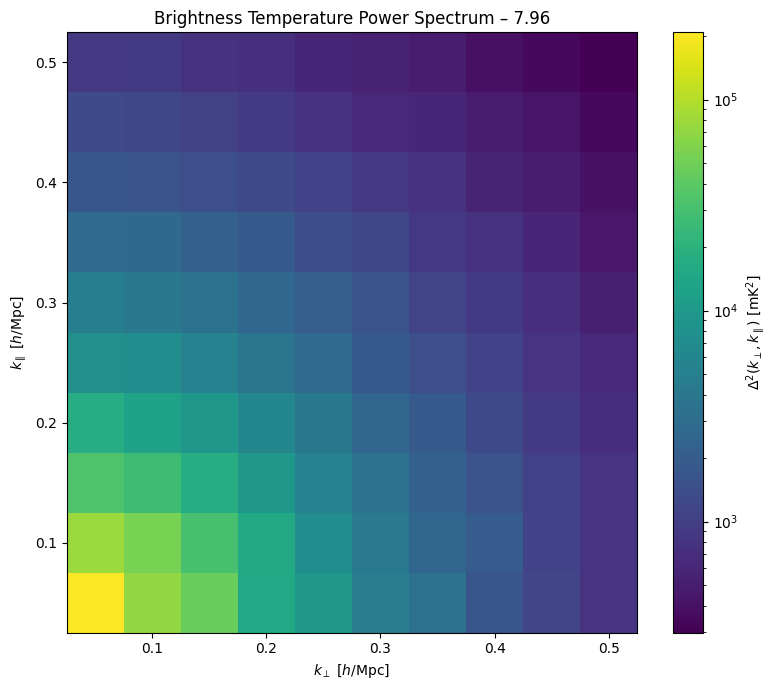

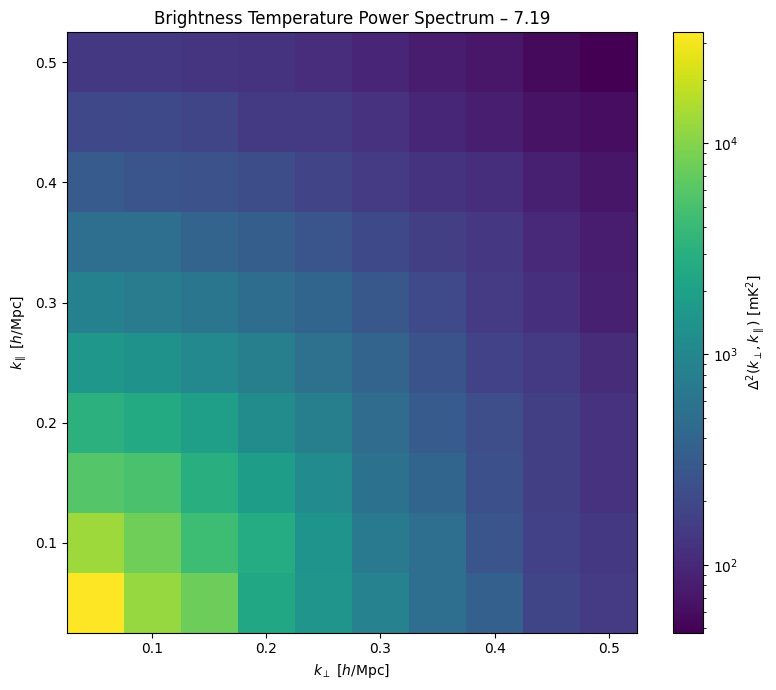

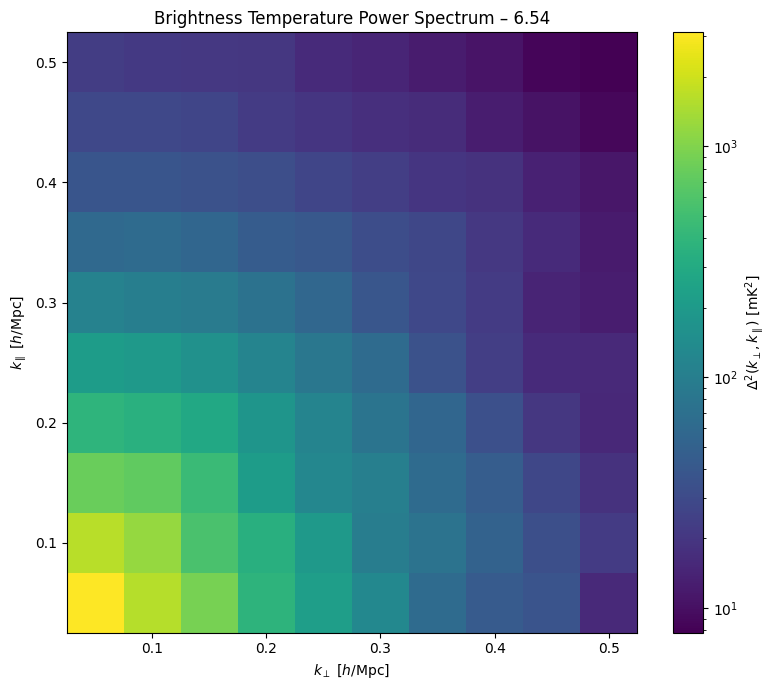

In [ ]:
from matplotlib.colors import LogNorm

for i in range(len(redshift_list)):
    kperp = kperp_list[i]
    kpar = kpar_list[i]
    delta2_2d = delta2_2d_list[i]
    ps2d = ps2d_list[i]
    z = redshift_list[i]

    plt.figure(figsize=(8, 7))
    
    # pcolormesh avec shading='flat' ou 'nearest' affiche les données brutes
    # On définit les limites des axes pour correspondre aux vecteurs k  
    pcm = plt.pcolormesh(kperp, kpar, ps2d, 
                         norm=LogNorm(vmin=ps2d.min(), vmax=ps2d.max()),
                         cmap='viridis')
    plt.colorbar(pcm, label=r'$\Delta^2(k_\perp, k_\parallel)$ [mK$^2$]')
    plt.xlabel(r'$k_\perp$ [$h$/Mpc]')
    plt.ylabel(r'$k_\parallel$ [$h$/Mpc]')
    plt.title(f'Brightness Temperature Power Spectrum – {z}')    
    plt.tight_layout()
    plt.show()

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import glob
from matplotlib.colors import LogNorm

kpar = np.loadtxt("PS1_PS2_Data/bins_kpar.txt")
kperp = np.loadtxt("PS1_PS2_Data/bins_kper.txt")

files = sorted(glob.glob("PS1_PS2_Data/Pk_PS2_*.txt"))

z_ranges = [
    "7.96",
    "7.19",
    "6.54"
]
ps2_true_list = []
z_ranges_list = []
for i, f in enumerate(files):

    data = np.loadtxt(f)
    ps2_true_list.append(data)
    z_ranges_list.append(z_ranges[i])

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import glob
from matplotlib.colors import LogNorm

kpar = np.loadtxt("PS1_PS2_Data/bins_kpar.txt")
kperp = np.loadtxt("PS1_PS2_Data/bins_kper.txt")

files = sorted(glob.glob("PS1_PS2_Data/err_Pk_PS2_*.txt"))
files_noise = sorted(glob.glob("PS1_PS2_Data/Pk_PS_averaged_noise_*.txt"))

z_ranges = [
    "7.96",
    "7.19",
    "6.54"
]
ps2_true_err_list = []
ps2_average_noise_list = []
for i, f in enumerate(files):
    data_std = np.loadtxt(f)
    data_average_noise = np.loadtxt(files_noise[i])
    ps2_true_err_list.append(data_std)
    ps2_average_noise_list.append(data_average_noise)

[[15.58755525  8.50584776  7.27397113  6.15552107  5.53692312  5.05116601
   4.65527635  4.40154996  4.21648975  3.91246965]
 [15.58755954  8.50584669  7.27396566  6.15552266  5.5369226   5.05116575
   4.65527645  4.40155214  4.2164898   3.91246916]
 [15.58755892  8.50585156  7.27396724  6.15552167  5.53692344  5.05116636
   4.65527608  4.4015523   4.2164898   3.91247015]
 [15.58755776  8.50584813  7.27396704  6.15552289  5.53692404  5.05116605
   4.65527664  4.40155189  4.21649011  3.91247047]
 [15.58755644  8.50584787  7.27396699  6.15552219  5.53692287  5.05116546
   4.65527666  4.40154957  4.21649017  3.91246979]
 [15.58755299  8.50584854  7.27396689  6.15552165  5.5369224   5.05116698
   4.65527606  4.40155233  4.21649062  3.91247074]
 [15.58755572  8.50584799  7.27396697  6.15552266  5.53692399  5.05116597
   4.65527688  4.40155153  4.21648818  3.91247025]
 [15.58755505  8.5058483   7.27396788  6.15552312  5.53692375  5.05116588
   4.65527665  4.4015514   4.21649026  3.91246882]


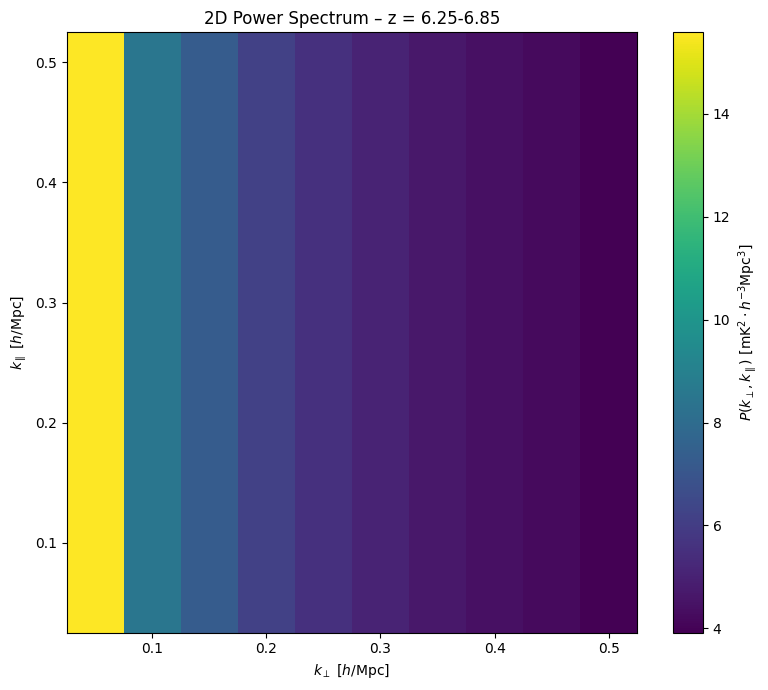

[[15.58755525  8.50584776  7.27397113  6.15552107  5.53692312  5.05116601
   4.65527635  4.40154996  4.21648975  3.91246965]
 [15.58755954  8.50584669  7.27396566  6.15552266  5.5369226   5.05116575
   4.65527645  4.40155214  4.2164898   3.91246916]
 [15.58755892  8.50585156  7.27396724  6.15552167  5.53692344  5.05116636
   4.65527608  4.4015523   4.2164898   3.91247015]
 [15.58755776  8.50584813  7.27396704  6.15552289  5.53692404  5.05116605
   4.65527664  4.40155189  4.21649011  3.91247047]
 [15.58755644  8.50584787  7.27396699  6.15552219  5.53692287  5.05116546
   4.65527666  4.40154957  4.21649017  3.91246979]
 [15.58755299  8.50584854  7.27396689  6.15552165  5.5369224   5.05116698
   4.65527606  4.40155233  4.21649062  3.91247074]
 [15.58755572  8.50584799  7.27396697  6.15552266  5.53692399  5.05116597
   4.65527688  4.40155153  4.21648818  3.91247025]
 [15.58755505  8.5058483   7.27396788  6.15552312  5.53692375  5.05116588
   4.65527665  4.4015514   4.21649026  3.91246882]


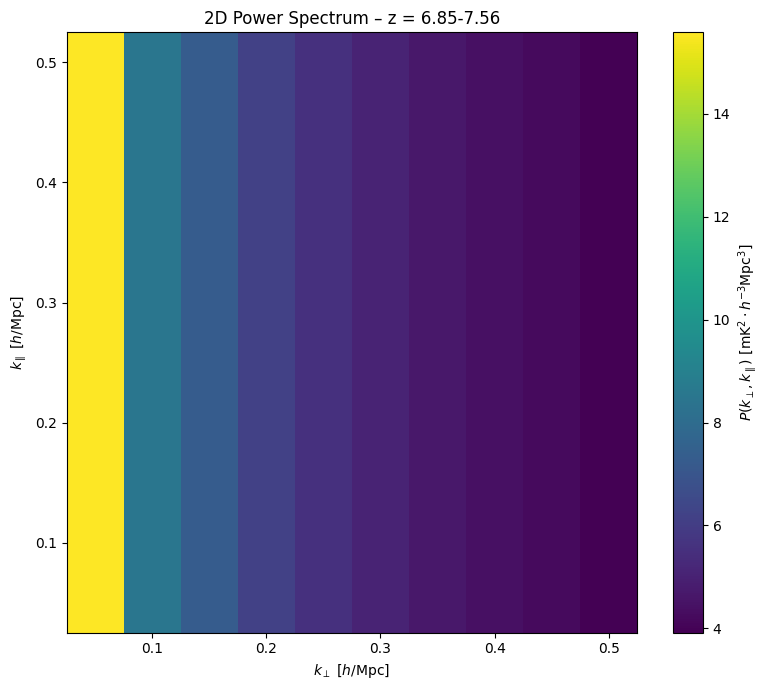

[[15.58755525  8.50584776  7.27397113  6.15552107  5.53692312  5.05116601
   4.65527635  4.40154996  4.21648975  3.91246965]
 [15.58755954  8.50584669  7.27396566  6.15552266  5.5369226   5.05116575
   4.65527645  4.40155214  4.2164898   3.91246916]
 [15.58755892  8.50585156  7.27396724  6.15552167  5.53692344  5.05116636
   4.65527608  4.4015523   4.2164898   3.91247015]
 [15.58755776  8.50584813  7.27396704  6.15552289  5.53692404  5.05116605
   4.65527664  4.40155189  4.21649011  3.91247047]
 [15.58755644  8.50584787  7.27396699  6.15552219  5.53692287  5.05116546
   4.65527666  4.40154957  4.21649017  3.91246979]
 [15.58755299  8.50584854  7.27396689  6.15552165  5.5369224   5.05116698
   4.65527606  4.40155233  4.21649062  3.91247074]
 [15.58755572  8.50584799  7.27396697  6.15552266  5.53692399  5.05116597
   4.65527688  4.40155153  4.21648818  3.91247025]
 [15.58755505  8.5058483   7.27396788  6.15552312  5.53692375  5.05116588
   4.65527665  4.4015514   4.21649026  3.91246882]


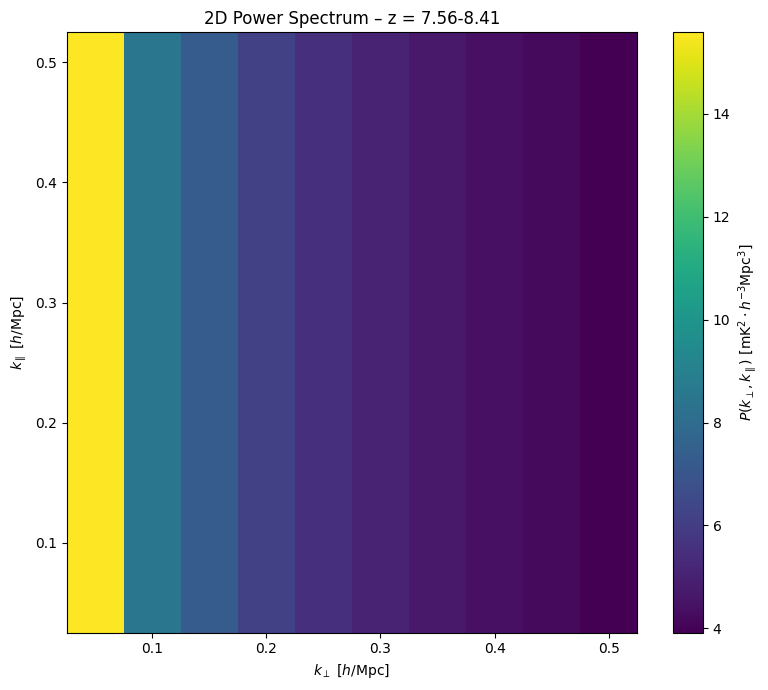

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import glob
from matplotlib.colors import LogNorm

# Chemin vers vos résultats
output_dir = "results_simu"
files = sorted(glob.glob(f"{output_dir}/data_z_*.npz"))
ps2d_list = []
for f in files:
    # 1. Charger le fichier .npz
    container = np.load(f)
    
    # 2. Extraire les données en utilisant les clés définies lors du np.savez
    ps2d = container['ps2d']
    kperp = container['kperp']
    kpar = container['kpar']
    
    # Extraire le redshift du nom du fichier pour le titre
    # (ou vous pouvez l'ajouter dans le np.savez lors de la simulation)
    z_str = f.split('_z_')[-1].replace('.npz', '')

    plt.figure(figsize=(8, 7))
    
    # 3. Affichage
    # Note : pcolormesh prend souvent les bords des bins. 
    # Si kperp et kpar sont les centres, le rendu sera correct avec shading='auto'
    fonction = (ps2_true_err_list[i]/ ps2_true_list[i])*100  # Ou ps2d selon ce que vous voulez afficher
    print(fonction)
    pcm = plt.pcolormesh(kperp, kpar, fonction, 
                         vmin=fonction[fonction > 0].min(), 
                         vmax=fonction.max(),
                         cmap='viridis',
                         shading='auto')
    plt.colorbar(pcm, label=r'$P(k_\perp, k_\parallel)$ [mK$^2 \cdot h^{-3} \text{Mpc}^3$]')
    plt.xlabel(r'$k_\perp$ [$h$/Mpc]')
    plt.ylabel(r'$k_\parallel$ [$h$/Mpc]')
    plt.title(f'2D Power Spectrum – z = {z_str}')
    plt.tight_layout()
    plt.show()

In [9]:
ps2d_pred = np.array(ps2d_list).flatten()
ps2_true = np.array(ps2_true_list).flatten()
ps2_std = (np.array(ps2_true_err_list)).flatten()

In [14]:
def compute_sigma():
    return ps2_std

def probability(y_true, y_pred):
    sigma = compute_sigma()
    chi_square_vec = y_true - y_pred
    norm = 1.0 / np.sqrt((2 * np.pi) ** len(sigma) * np.prod(sigma ** 2))
    exponent = -0.5 * np.sum((chi_square_vec / sigma) ** 2)
    return exponent   

In [15]:
probability(ps2_true, ps2d_pred)

np.float64(-8675.68784015305)